In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
datasetPath = Path("/home/philipm/Desktop/ML-For-CV-Robustness/datasets/notrees.csv")

#making sure
datasetPath.is_file()

True

In [3]:
dataset = pd.read_csv(datasetPath)
dataset.head()

,grviIn,meanRefR,meanRefG,illumR,illumG,blockIdx,sunRoll,sunPitch,sunYaw,camRoll,camPitch,camYaw,grviOut
0,0.163549,0.000324,0.000421,1130.973355,1020.232214,0.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.088270
1,0.097110,0.000412,0.000486,1130.973355,1020.232214,1.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.057202
2,0.074345,0.000448,0.000517,1130.973355,1020.232214,2.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.048503
3,0.156574,0.000374,0.000481,1130.973355,1020.232214,3.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.086477
4,0.116627,0.000393,0.000479,1130.973355,1020.232214,4.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.067095


In [4]:
target_col = dataset["grviOut"]
labels = target_col.to_numpy(dtype="float32")
labels

array([0.08826979, 0.05720193, 0.04850335, ..., 0.09717431, 0.09026365,
       0.10635003], shape=(333480,), dtype=float32)

In [5]:
inputs = dataset.drop("grviOut", axis=1)
inputs = inputs.to_numpy(dtype="float32")
inputs

array([[ 1.6354947e-01,  3.2419228e-04,  4.2050949e-04, ...,
         0.0000000e+00, -1.9257999e+01, -0.0000000e+00],
       [ 9.7109884e-02,  4.1166358e-04,  4.8633927e-04, ...,
         0.0000000e+00, -1.9257999e+01, -0.0000000e+00],
       [ 7.4344695e-02,  4.4785510e-04,  5.1731960e-04, ...,
         0.0000000e+00, -1.9257999e+01, -0.0000000e+00],
       ...,
       [ 2.8433150e-01,  2.7023174e-04,  4.2468391e-04, ...,
        -0.0000000e+00, -2.2218000e+01, -1.8000000e+02],
       [ 2.4198939e-01,  3.4632298e-04,  5.1073608e-04, ...,
        -0.0000000e+00, -2.2218000e+01, -1.8000000e+02],
       [ 2.7564889e-01,  3.2772828e-04,  5.1514880e-04, ...,
        -0.0000000e+00, -2.2218000e+01, -1.8000000e+02]],
      shape=(333480, 12), dtype=float32)

In [6]:
if len(labels) != len (inputs):
    print ("problem")

In [7]:
n_total = len(inputs)

n_train = int(0.8*n_total)
n_test = int(0.1*n_total)
n_val = int(0.1*n_total)

# shuffle
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator=g).numpy()

inputs_shuf = inputs[perm]
labels_shuf = labels[perm]

# split
train_inputs, train_labels = inputs_shuf[:n_train], labels_shuf[:n_train]
val_inputs, val_labels = inputs_shuf[n_train:n_train + n_val], labels_shuf[n_train:n_train + n_val]
test_inputs, test_labels = inputs_shuf[n_train + n_val:], labels_shuf[n_train + n_val:]

In [8]:
# scaling
from sklearn.preprocessing import QuantileTransformer, StandardScaler

if True:
    input_scaler = StandardScaler() #QuantileTransformer(output_distribution='normal')
    target_scaler = StandardScaler()

    train_inputs = input_scaler.fit_transform(train_inputs)
    train_labels = target_scaler.fit_transform(train_labels.reshape(-1, 1)).reshape(-1)

    val_inputs = input_scaler.transform(val_inputs)
    val_labels = target_scaler.transform(val_labels.reshape(-1, 1)).reshape(-1)

    test_inputs = input_scaler.transform(test_inputs)
    test_labels = target_scaler.transform(test_labels.reshape(-1, 1)).reshape(-1)

In [9]:
train_inputs = torch.from_numpy(train_inputs).float()
train_labels = torch.from_numpy(train_labels).float()

val_inputs = torch.from_numpy(val_inputs).float()
val_labels = torch.from_numpy(val_labels).float()

test_inputs = torch.from_numpy(test_inputs).float()
test_labels = torch.from_numpy(test_labels).float()

In [10]:
print ("Train size:", len(train_inputs))
print ("Val size:", len(val_inputs))
print ("Test size:", len(test_inputs))

Train size: 266784
Val size: 33348
Test size: 33348


In [11]:
BATCH_SIZE = 512

class metricsDataset (Dataset):
    def __init__(self, metrics, labels):
        self.metrics = metrics
        self.labels = labels

    def __len__(self):
        return len(self.metrics)

    def __getitem__(self, idx):
        return self.metrics[idx], self.labels[idx]

train_dataset = metricsDataset(train_inputs, train_labels)
val_dataset   = metricsDataset(val_inputs, val_labels)
test_dataset  = metricsDataset(test_inputs, test_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    pin_memory=True
)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [13]:
model = nn.Sequential(
    nn.Linear(12, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    nn.Linear(64, 1)
).to(device)

In [15]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=0.01
)

In [16]:
EPOCHS = 160

best_val_loss = float("inf")

for epoch in range(0, EPOCHS):
    model.train()
    train_loss = 0.0

    for x, y in train_loader:
        optimizer.zero_grad()

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        preds = model(x).squeeze(-1)
        loss = criterion(preds, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(x).squeeze(-1)
            loss = criterion(pred, y)

            val_loss += loss.item() * x.size(0)

    val_loss /= len(val_loader.dataset)

    print(
        f"Epoch {epoch + 1:3d}/{EPOCHS} | "
        f"Train MSE: {train_loss:.6f} | "
        f"Val MSE: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        # SAVE the model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
        }, 'best_model_checkpoint.pth')

        print("Best Model Saved")

checkpoint = torch.load('best_model_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model (Val Loss: {checkpoint['best_val_loss']})")

model.eval()
test_loss = 0.0
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        pred = model(x).squeeze(-1)
        loss = criterion(pred, y)
        test_loss += loss.item() * x.size(0)

test_loss /= len(test_loader.dataset)
print(f"\nTest MSE: {test_loss:.6f}")
print(f"Test RMSE: {test_loss ** 0.5:.6f}")

Epoch   1/160 | Train MSE: 0.269780 | Val MSE: 0.346571
Best Model Saved
Epoch   2/160 | Train MSE: 0.168981 | Val MSE: 0.149456
Best Model Saved
Epoch   3/160 | Train MSE: 0.157567 | Val MSE: 0.143087
Best Model Saved
Epoch   4/160 | Train MSE: 0.150425 | Val MSE: 0.140762
Best Model Saved
Epoch   5/160 | Train MSE: 0.147502 | Val MSE: 0.133656
Best Model Saved
Epoch   6/160 | Train MSE: 0.143642 | Val MSE: 0.132083
Best Model Saved
Epoch   7/160 | Train MSE: 0.141210 | Val MSE: 0.323841
Epoch   8/160 | Train MSE: 0.141493 | Val MSE: 0.150116
Epoch   9/160 | Train MSE: 0.138145 | Val MSE: 0.129216
Best Model Saved
Epoch  10/160 | Train MSE: 0.135945 | Val MSE: 0.124985
Best Model Saved
Epoch  11/160 | Train MSE: 0.133647 | Val MSE: 0.130798
Epoch  12/160 | Train MSE: 0.133276 | Val MSE: 0.389723
Epoch  13/160 | Train MSE: 0.130769 | Val MSE: 0.169225
Epoch  14/160 | Train MSE: 0.130530 | Val MSE: 0.369607
Epoch  15/160 | Train MSE: 0.130224 | Val MSE: 0.156714
Epoch  16/160 | Train MS

In [17]:
rel_test_loss = (test_loss**0.5)*100 / (test_labels.max()-test_labels.min())
print(str(float(rel_test_loss)) + "%")

3.8544349670410156%


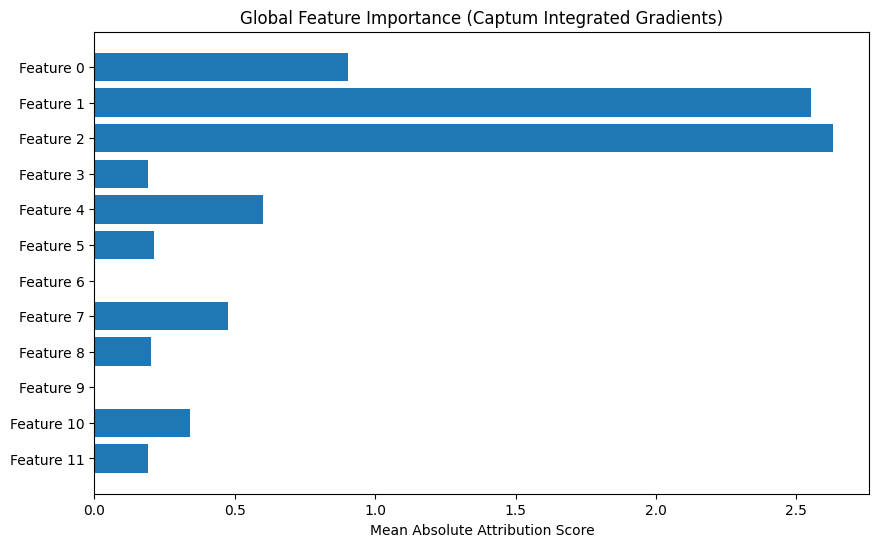

In [24]:
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt

model.eval()
ig = IntegratedGradients(model)

all_attributions = []


for inputs, labels in test_loader:
    inputs = inputs.to(device)
    inputs.requires_grad_()
    
    batch_attributions = ig.attribute(inputs, target=0)
    
    all_attributions.append(batch_attributions.detach().cpu())

global_attributions = torch.cat(all_attributions, dim=0)

mean_importance = torch.abs(global_attributions).mean(dim=0).numpy()

feature_names = [f"Feature {i}" for i in range(len(mean_importance))] # Replace with your column names

plt.figure(figsize=(10, 6))
plt.barh(feature_names, mean_importance)
plt.title("Global Feature Importance (Captum Integrated Gradients)")
plt.xlabel("Mean Absolute Attribution Score")
plt.gca().invert_yaxis() # Put the most important at the top if sorted
plt.show()